# NSE stock analysis: exploration

Same analysis as the Streamlit app, step by step. Everything is read from `data/nse.db`, so run `python -m src.fetch_data` first if the database is missing.

In [1]:
import sys
sys.path.append('..')  # so the notebook can import config and src from the project folder

import pandas as pd
import plotly.io as pio

import config
from src import analytics, charts, queries

pio.renderers.default = 'png'  # static images, so the charts also show on GitHub
# Use the full date range that is stored in the database
START, END = queries.read_sql('SELECT MIN(date), MAX(date) FROM prices').iloc[0]
print(START, 'to', END)

2021-10-05 to 2026-10-05


## 1. What is in the database

One row per stock in `stocks`, one row per stock per day in `prices`.

In [2]:
queries.read_sql('''
    SELECT s.ticker, s.company_name, s.sector, COUNT(*) AS days, MIN(p.date) AS first_day, MAX(p.date) AS last_day
    FROM stocks s JOIN prices p ON p.ticker = s.ticker
    GROUP BY s.ticker ORDER BY s.sector
''')

,ticker,company_name,sector,days,first_day,last_day
0,HDFCBANK.NS,HDFC Bank,Banking,1234,2021-10-05,2026-10-05
1,ICICIBANK.NS,ICICI Bank,Banking,1234,2021-10-05,2026-10-05
2,SBIN.NS,State Bank of India,Banking,1234,2021-10-05,2026-10-05
3,RELIANCE.NS,Reliance Industries,Energy,1234,2021-10-05,2026-10-05
4,HINDUNILVR.NS,Hindustan Unilever,FMCG,1234,2021-10-05,2026-10-05
5,ITC.NS,ITC,FMCG,1235,2021-10-05,2026-10-05
6,INFY.NS,Infosys,IT,1234,2021-10-05,2026-10-05
7,TCS.NS,Tata Consultancy Services,IT,1234,2021-10-05,2026-10-05
8,^NSEI,Nifty 50,Index,1235,2021-10-05,2026-10-05
9,LT.NS,Larsen & Toubro,Infrastructure,1234,2021-10-05,2026-10-05


## 2. Daily returns (SQL query 1)

The return is calculated in SQL with `LAG()`. Here it is reshaped so each ticker is a column.

In [3]:
daily = queries.run_query('daily_returns', START, END)
returns = daily.pivot(index='date', columns='ticker', values='daily_return')
prices = daily.pivot(index='date', columns='ticker', values='adj_close')
(returns.describe().T[['count', 'mean', 'std', 'min', 'max']] * [1, 100, 100, 100, 100]).round(2)

,count,mean,std,min,max
ticker,,,,,
HDFCBANK.NS,1233.0,0.00,1.33,-8.44,10.01
HINDUNILVR.NS,1233.0,-0.02,1.30,-7.40,5.96
ICICIBANK.NS,1233.0,0.06,1.27,-7.63,10.85
INFY.NS,1233.0,-0.02,1.64,-9.42,7.93
ITC.NS,1234.0,0.04,1.27,-9.71,5.50
LT.NS,1233.0,0.08,1.54,-12.67,7.59
RELIANCE.NS,1233.0,0.01,1.41,-7.49,7.02
SBIN.NS,1233.0,0.08,1.54,-14.40,9.07
SUNPHARMA.NS,1233.0,0.07,1.26,-4.55,6.98


## 3. Risk and return per stock

Annualised return (CAGR), volatility, Sharpe ratio with a 7% risk-free rate, max drawdown and beta against the Nifty 50. Sorted by Sharpe ratio.

In [4]:
summary = analytics.summary_table(returns, prices, config.BENCHMARK, config.RISK_FREE_RATE)
summary.sort_values('sharpe', ascending=False).round(3)

,ann_return,ann_volatility,sharpe,max_drawdown,beta
ticker,,,,,
SUNPHARMA.NS,0.183,0.200,0.566,-0.191,0.565
LT.NS,0.185,0.245,0.471,-0.289,1.198
SBIN.NS,0.181,0.245,0.451,-0.239,1.162
ICICIBANK.NS,0.151,0.202,0.398,-0.223,0.970
ITC.NS,0.080,0.201,0.048,-0.449,0.667
^NSEI,0.049,0.138,-0.150,-0.172,1.000
RELIANCE.NS,0.001,0.224,-0.310,-0.272,1.116
HDFCBANK.NS,-0.012,0.211,-0.388,-0.310,1.061
INFY.NS,-0.072,0.261,-0.545,-0.482,0.965


## 4. Growth of 100 rupees

Four stocks from different sectors against the Nifty 50, starting at 100.

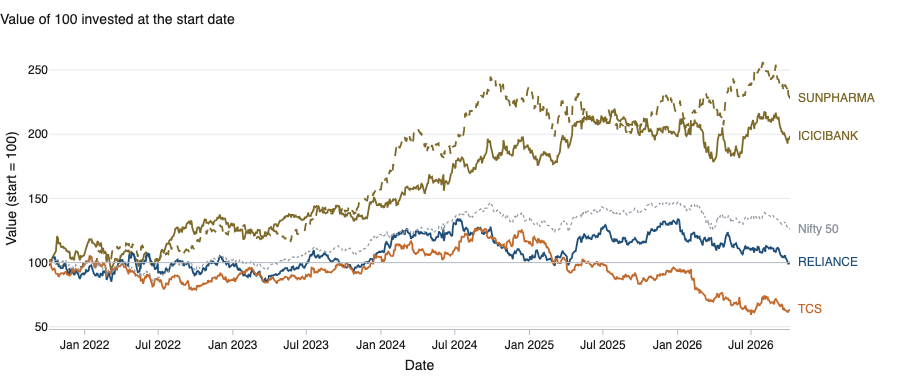

In [5]:
picked = ['SUNPHARMA.NS', 'ICICIBANK.NS', 'RELIANCE.NS', 'TCS.NS', config.BENCHMARK]
rebased = prices[picked] / prices[picked].bfill().iloc[0] * 100
charts.cumulative_chart(rebased).update_layout(width=900).show()

## 5. Correlation between stocks

Correlation of daily returns for all 10 stocks. Stocks in the same sector (TCS and Infosys, the three banks) should be the most correlated.

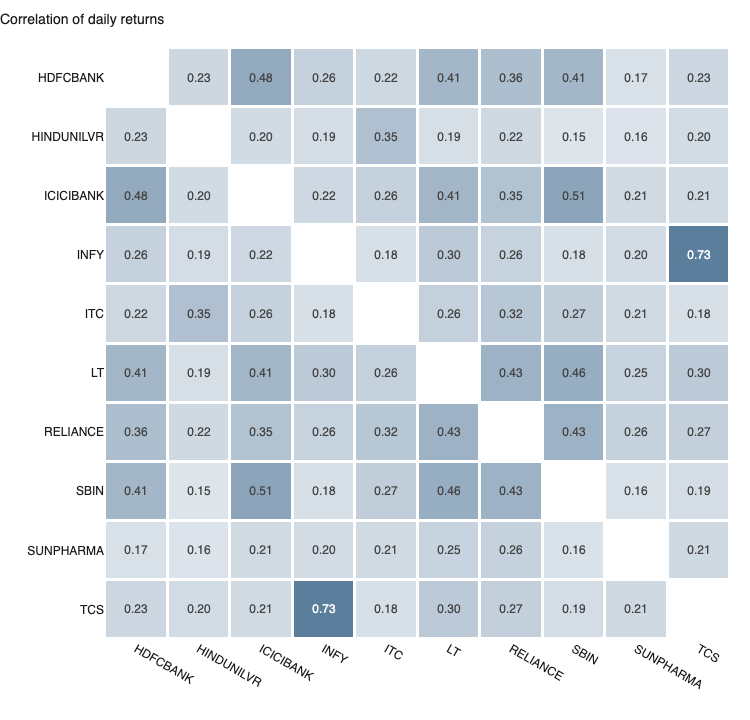

In [6]:
corr = analytics.correlation_matrix(returns.drop(columns=config.BENCHMARK))
charts.correlation_heatmap(corr).update_layout(width=750).show()

## 6. Sectors (SQL query 3)

Pooled daily returns per sector. Volatility is worked out in SQL from AVG(r*r) - AVG(r)^2.

In [7]:
sector = queries.run_query('sector_risk_return', START, END)
sector

,sector,stocks,avg_daily_return_pct,daily_volatility_pct,ann_return_pct,ann_volatility_pct
0,Infrastructure,1,0.079,1.542,20.02,24.48
1,Pharma,1,0.075,1.260,18.84,20.01
2,Banking,3,0.049,1.387,12.25,22.01
3,Index,1,0.023,0.871,5.77,13.82
4,FMCG,2,0.011,1.281,2.83,20.34
5,Energy,1,0.010,1.408,2.58,22.35
6,IT,2,-0.021,1.539,-5.41,24.44


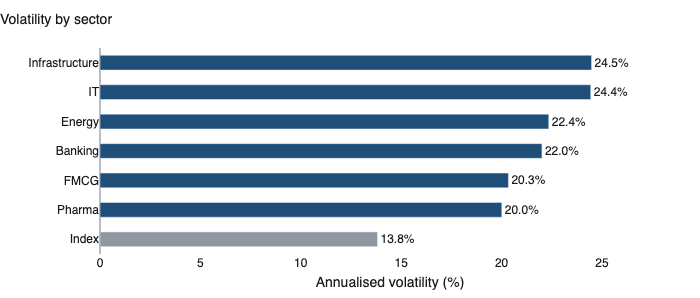

In [8]:
charts.bar_chart(sector.set_index('sector')['ann_volatility_pct'], 'Volatility by sector',
                  'Annualised volatility (%)', highlight='Index').update_layout(width=700).show()

## 7. Days above the 200-day moving average (SQL query 6)

In [9]:
queries.run_query('days_above_ma200', START, END)

,ticker,company_name,days,pct_above,pct_below
0,LT.NS,Larsen & Toubro,1035,82.4,17.6
1,ICICIBANK.NS,ICICI Bank,1035,82.0,18.0
2,SUNPHARMA.NS,Sun Pharmaceutical,1035,80.8,19.2
3,SBIN.NS,State Bank of India,1035,79.4,20.6
4,^NSEI,Nifty 50,1036,74.9,25.1
5,HDFCBANK.NS,HDFC Bank,1035,63.7,36.3
6,RELIANCE.NS,Reliance Industries,1035,56.7,43.3
7,ITC.NS,ITC,1036,49.3,50.7
8,TCS.NS,Tata Consultancy Services,1035,43.1,56.9
9,HINDUNILVR.NS,Hindustan Unilever,1035,40.4,59.6


## 8. Largest single-day moves (SQL query 4)

In [10]:
queries.run_query('biggest_moves', START, END)

,move,company_name,sector,date,return_pct
0,Best,ICICI Bank,Banking,2021-10-25,10.85
1,Best,HDFC Bank,Banking,2022-04-04,10.01
2,Best,State Bank of India,Banking,2024-06-03,9.07
3,Best,Infosys,IT,2024-01-12,7.93
4,Best,Infosys,IT,2025-05-12,7.91
5,Worst,State Bank of India,Banking,2024-06-04,-14.40
6,Worst,Larsen & Toubro,Infrastructure,2024-06-04,-12.67
7,Worst,ITC,FMCG,2026-01-01,-9.71
8,Worst,Infosys,IT,2023-04-17,-9.42
9,Worst,HDFC Bank,Banking,2024-01-17,-8.44
